In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('final_data_cleaned.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  float64
 2   LoanAmount                    255347 non-null  float64
 3   CreditScore                   255347 non-null  float64
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   Default                       255347 non-null  int64  
 10  Education_High School         255347 non-null  bool   
 11  Education_Master's            255347 non-null  bool   
 12  Education_PhD                 255347 non-nul

In [9]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['age', 'income', 'loanamount', 'creditscore', 'monthsemployed',
       'numcreditlines', 'interestrate', 'loanterm', 'dtiratio', 'default',
       'education_high school', 'education_master's', 'education_phd',
       'employmenttype_part-time', 'employmenttype_self-employed',
       'employmenttype_unemployed', 'maritalstatus_married',
       'maritalstatus_single', 'hasmortgage_yes', 'hasdependents_yes',
       'loanpurpose_business', 'loanpurpose_education', 'loanpurpose_home',
       'loanpurpose_other', 'hascosigner_yes'],
      dtype='object')


In [10]:
print(df.columns)

Index(['age', 'income', 'loanamount', 'creditscore', 'monthsemployed',
       'numcreditlines', 'interestrate', 'loanterm', 'dtiratio', 'default',
       'education_high school', 'education_master's', 'education_phd',
       'employmenttype_part-time', 'employmenttype_self-employed',
       'employmenttype_unemployed', 'maritalstatus_married',
       'maritalstatus_single', 'hasmortgage_yes', 'hasdependents_yes',
       'loanpurpose_business', 'loanpurpose_education', 'loanpurpose_home',
       'loanpurpose_other', 'hascosigner_yes'],
      dtype='object')


In [12]:
X = df.drop('default', axis=1)
y = df['default']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (255347, 24)
Target shape: (255347,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [17]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.7511894164499066


In [18]:
coeff = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Features Increasing Default Risk:")
print(coeff.head(10))

print("\nTop Features Decreasing Default Risk:")
print(coeff.tail(10))


Top Features Increasing Default Risk:
                         Feature  Coefficient
6                   interestrate     0.453388
2                     loanamount     0.283833
14     employmenttype_unemployed     0.195006
12      employmenttype_part-time     0.124093
13  employmenttype_self-employed     0.108091
5                 numcreditlines     0.101287
8                       dtiratio     0.060388
9          education_high school     0.031235
19          loanpurpose_business     0.024588
20         loanpurpose_education     0.000094

Top Features Decreasing Default Risk:
                  Feature  Coefficient
11          education_phd    -0.066913
21       loanpurpose_home    -0.077991
17        hasmortgage_yes    -0.079814
15  maritalstatus_married    -0.099304
18      hasdependents_yes    -0.120474
3             creditscore    -0.120744
23        hascosigner_yes    -0.136614
1                  income    -0.320272
4          monthsemployed    -0.335390
0                     age 

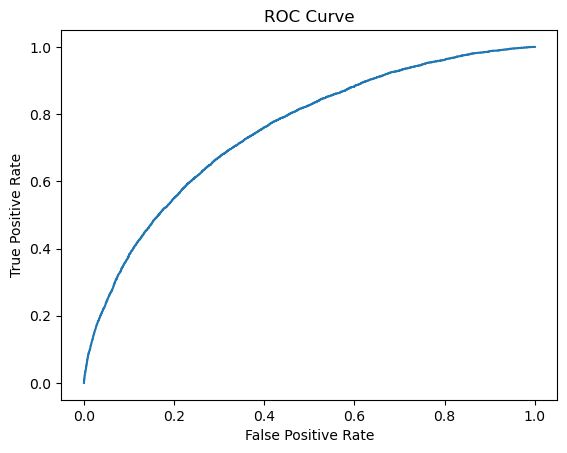

In [19]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()